## 1. Importing Packages

In [1]:
import os
import cv2
import time
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models

from datasets import load_dataset
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize


## 2. Download Dataset (HuggingFace)

In [2]:
dataset = load_dataset("beans")  # HuggingFace beans dataset

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 1034
    })
    validation: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 133
    })
    test: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 128
    })
})


## 3. Data Preprocessing & Augmentation

In [3]:
# ImageNet normalization (best practice for deep learning)
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]
size = (128,128)

# Training Transform (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize(size),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
]) 

# Validation & Test Transform (NO augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize(size),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

## 4. Dataset Overview & Statistics

In [4]:
train_data = datasets.ImageFolder("dataset/train", transform=train_transform)
val_data   = datasets.ImageFolder("dataset/val", transform=val_test_transform)
test_data  = datasets.ImageFolder("dataset/test", transform=val_test_transform)

In [5]:
class_names = train_data.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['angular_leaf_spot', 'bean_rust', 'healthy']
Number of classes: 3


In [6]:
print("Training samples:", len(train_data))
print("Validation samples:", len(val_data))
print("Test samples:", len(test_data))

Training samples: 3102
Validation samples: 399
Test samples: 384


In [7]:
labels = [label for _, label in train_data]
label_counts = Counter(labels)

for i, count in label_counts.items():
    print(f"{class_names[i]}: {count}")

angular_leaf_spot: 1035
bean_rust: 1044
healthy: 1023


/var/folders/d5/q2cn21ss0kqdyvj9bn7bg10r0000gn/T/ipykernel_3960/1220893731.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


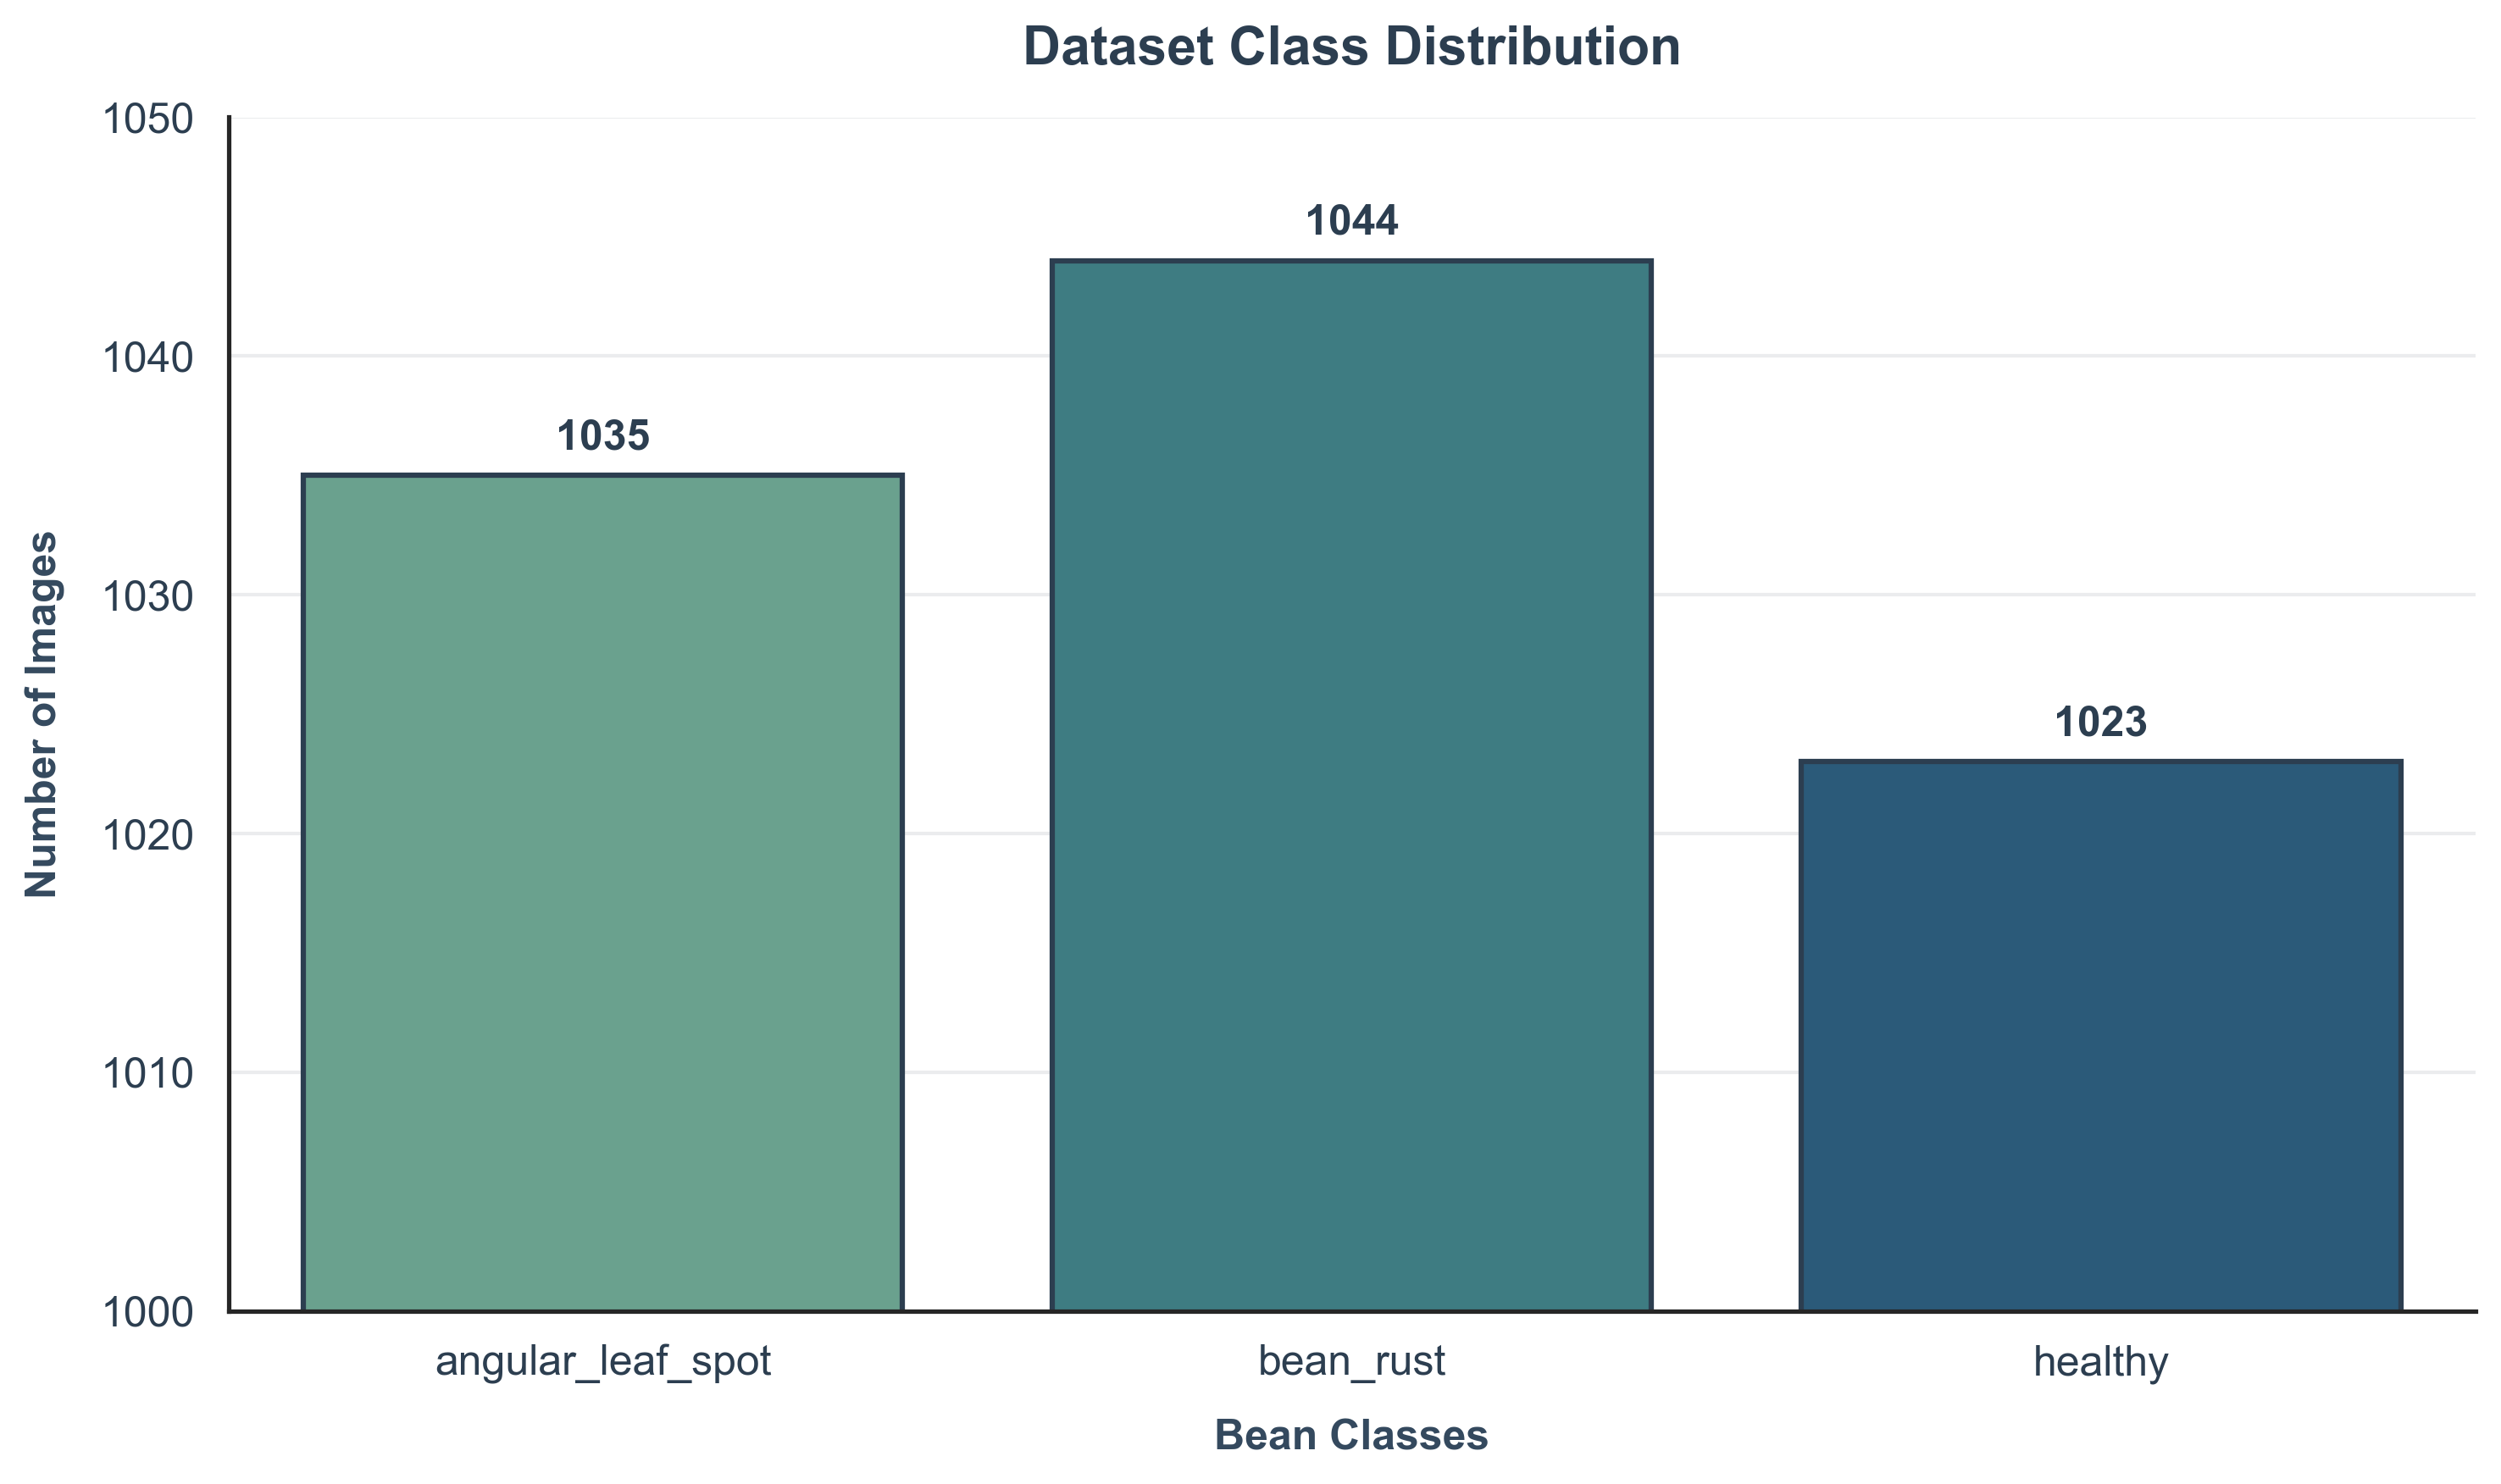

In [8]:
counts = [label_counts[i] for i in range(len(class_names))]
sns.set_theme(style="white", rc={"axes.spines.top": False, "axes.spines.right": False})
plt.figure(figsize=(10,6), dpi=300)
ax = sns.barplot(
    x=class_names, 
    y=counts, 
    palette="crest",       
    edgecolor="#2c3e50",   
    linewidth=1.5
)
plt.ylim(1000, 1050)
plt.title("Dataset Class Distribution", fontsize=15, fontweight='bold', pad=15, color="#2c3e50")
plt.xlabel("Bean Classes", fontsize=12, fontweight='bold', labelpad=10, color="#34495e")
plt.ylabel("Number of Images", fontsize=12, fontweight='bold', labelpad=10, color="#34495e")
plt.xticks(fontsize=12, color="#2c3e50")
plt.yticks(fontsize=12, color="#2c3e50")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom',  # changed va to 'bottom' so text stays above the bar
                fontsize=12, fontweight='bold', color='#2c3e50', 
                xytext=(0, 5), textcoords='offset points')
plt.grid(axis='y', linestyle='-', alpha=0.3, color='#bdc3c7')
plt.tight_layout()
plt.show()

In [9]:
base_path = "dataset"

for split in ["train", "val", "test"]:
    split_path = os.path.join(base_path, split)
    print(f"\n {split.upper()} FOLDER:")
    
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        
        # Skip non-directories (fixes .DS_Store issue)
        if not os.path.isdir(class_path):
            continue
        
        num_images = len(os.listdir(class_path))
        print(f"  {class_name}: {num_images} images")


 TRAIN FOLDER:
  healthy: 1023 images
  angular_leaf_spot: 1035 images
  bean_rust: 1044 images

 VAL FOLDER:
  healthy: 132 images
  angular_leaf_spot: 132 images
  bean_rust: 135 images

 TEST FOLDER:
  healthy: 126 images
  angular_leaf_spot: 129 images
  bean_rust: 129 images


In [10]:
train_size = len(train_data)
val_size   = len(val_data)
test_size  = len(test_data)

total = train_size + val_size + test_size

print(f"Train Samples: {train_size}")
print(f"Validation Samples: {val_size}")
print(f"Test Samples: {test_size}")
print(f"Total Samples: {total}")

Train Samples: 3102
Validation Samples: 399
Test Samples: 384
Total Samples: 3885


In [11]:
train_pct = (train_size / total) * 100
val_pct   = (val_size / total) * 100
test_pct  = (test_size / total) * 100

print(f"Train: {train_pct:.2f}%")
print(f"Validation: {val_pct:.2f}%")
print(f"Test: {test_pct:.2f}%")

Train: 79.85%
Validation: 10.27%
Test: 9.88%


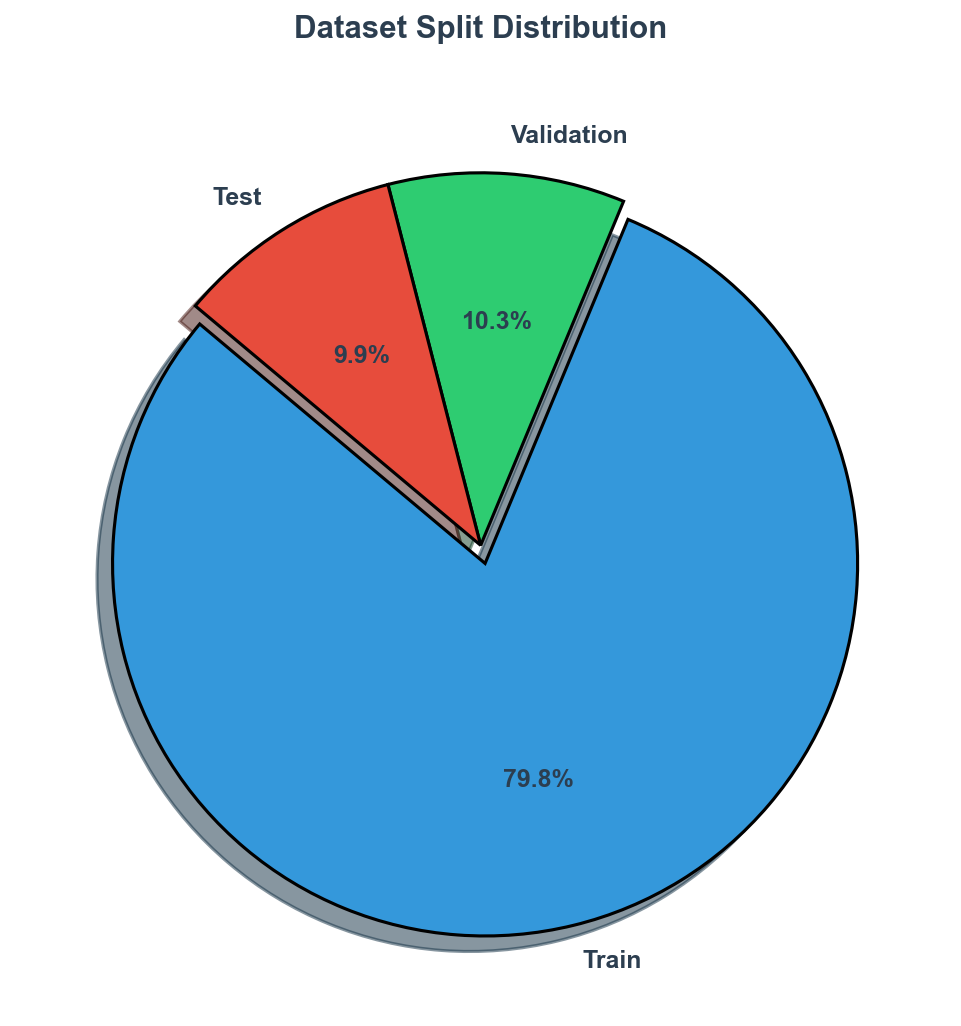

In [209]:

labels = ["Train", "Validation", "Test"]
sizes = [train_size, val_size, test_size]

colors = ["#3498db", "#2ecc71", "#e74c3c"]
explode = (0.05, 0, 0)

plt.figure(figsize=(7, 7), dpi=150)
plt.pie(
    sizes, 
    labels=labels, 
    colors=colors, 
    autopct='%1.1f%%', 
    startangle=140, 
    explode=explode,
    shadow=True,
    textprops={"fontsize": 12, "fontweight": "bold", "color": "#2c3e50"},
    wedgeprops={"edgecolor": "black", "linewidth": 1.5, "antialiased": True}
)

plt.title("Dataset Split Distribution", fontsize=15, fontweight="bold", pad=20, color="#2c3e50")
plt.tight_layout()
plt.show()


## 5. Data Visualisation

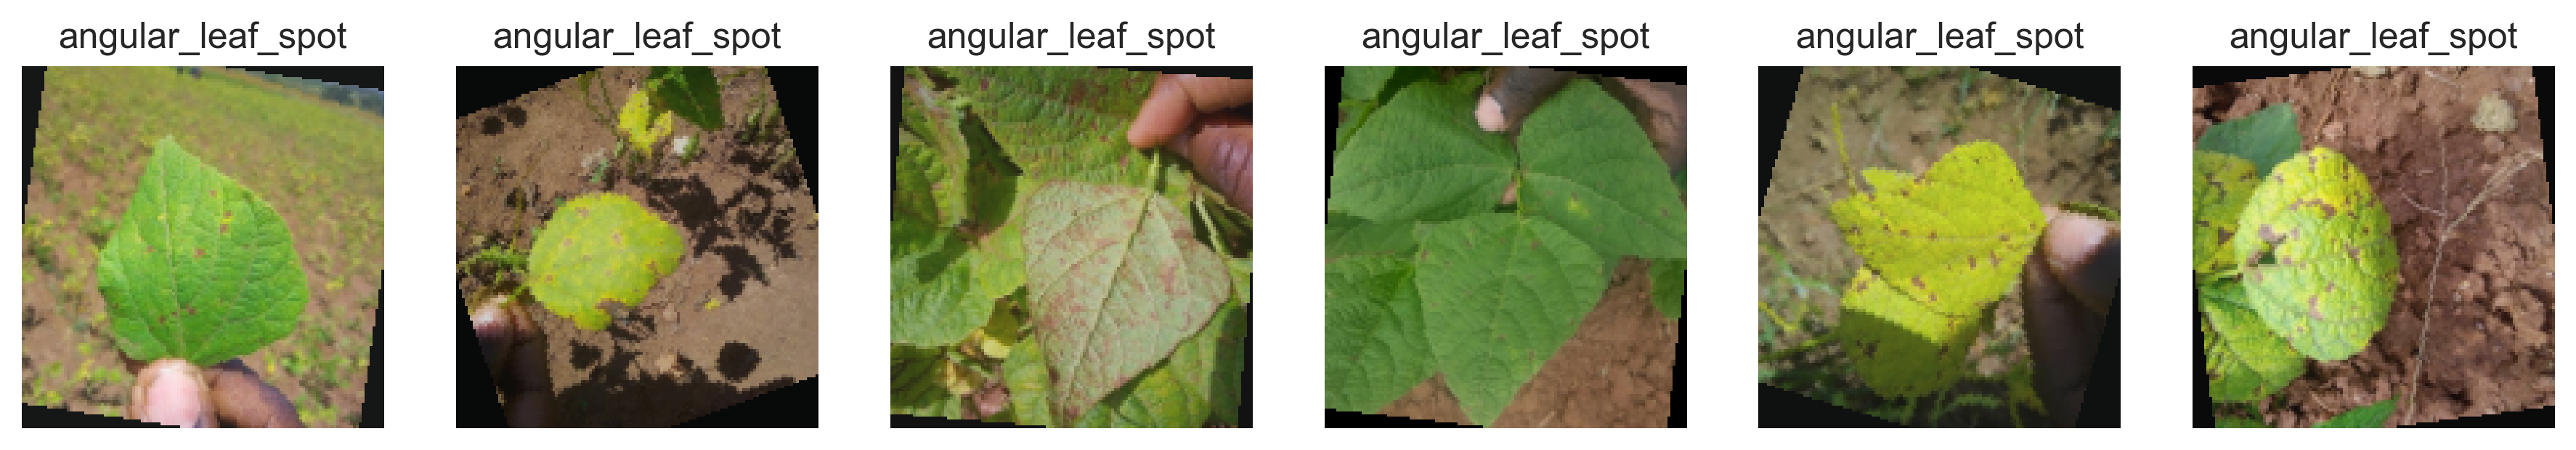

In [13]:
def show_images(dataset, num_images=6):
    fig, axes = plt.subplots(1, num_images, figsize=(15,5),dpi=300)
    
    for i in range(num_images):
        img, label = dataset[i]
        img = img.permute(1, 2, 0).numpy()
        
        # Unnormalize for display
        img = (img * std) + mean
        img = img.clip(0,1)
        
        axes[i].imshow(img)
        axes[i].set_title(class_names[label])
        axes[i].axis("off")
    
    plt.show()

show_images(train_data)

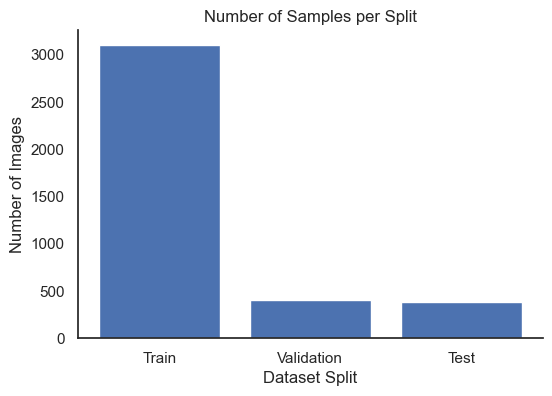

In [14]:
plt.figure(figsize=(6,4))
plt.bar(labels, sizes)
plt.title("Number of Samples per Split")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.show()

## 6. Data Loaders

In [15]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,          # shuffle for training
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [16]:
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 49
Validation batches: 7
Test batches: 6


In [17]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

/opt/homebrew/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Image batch shape: torch.Size([64, 3, 128, 128])
Label batch shape: torch.Size([64])


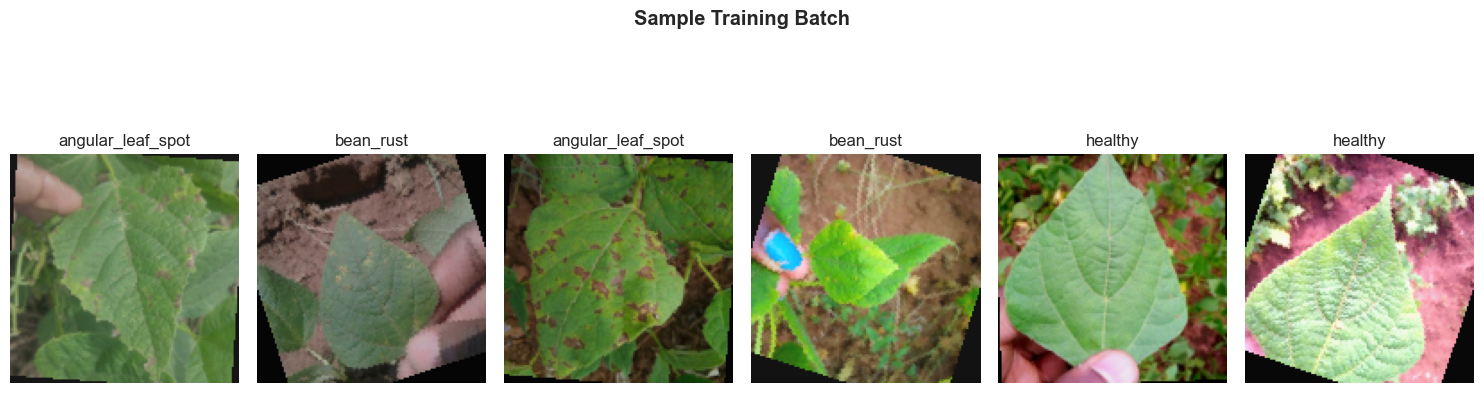

In [18]:
def show_batch(images, labels):
    fig, axes = plt.subplots(1, 6, figsize=(15, 5))
    mean_np = np.array([0.485, 0.456, 0.406])
    std_np  = np.array([0.229, 0.224, 0.225])
    for i in range(6):
        img = images[i].permute(1, 2, 0).numpy()
        img = (img * std_np) + mean_np
        img = img.clip(0, 1)
        axes[i].imshow(img)
        axes[i].set_title(train_data.classes[labels[i]])
        axes[i].axis("off")
    plt.suptitle("Sample Training Batch", fontweight="bold")
    plt.tight_layout()
    plt.show()

show_batch(images, labels)

## 7. Baseline CNN Architecture

In [19]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super(BaselineCNN, self).__init__()
        
        # Convolution layers
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        
        # Pooling
        self.pool = nn.MaxPool2d(2, 2)
        
        # Fully connected layers
        self.fc1 = nn.Linear(32 * 32 * 32, 128)  # 128x128 → 32x32 after pooling
        self.fc2 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # [B,16,64,64]
        x = self.pool(F.relu(self.conv2(x)))   # [B,32,32,32]
        
        x = x.view(x.size(0), -1)              # flatten
        
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(train_data.classes)
model = BaselineCNN(num_classes).to(device)
print(model)

BaselineCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32768, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)


In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 8. Training Loop

In [22]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    for epoch in range(epochs):
        # ===== TRAINING =====
        model.train()
        running_loss = 0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # ===== VALIDATION =====
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct / total
        
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        # ===== PRINT PROGRESS =====
        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        print("-"*40)
    
    return train_losses, val_losses, train_accs, val_accs

In [23]:
start_baseline = time.time()

train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, criterion, optimizer, epochs=10
)

baseline_time = time.time() - start_baseline
print(f"Baseline CNN Training Time: {baseline_time:.1f}s")

Epoch [1/10]
Train Loss: 0.9493 | Train Acc: 62.22%
Val Loss: 0.6268 | Val Acc: 66.17%
----------------------------------------
Epoch [2/10]
Train Loss: 0.6202 | Train Acc: 73.34%
Val Loss: 0.5319 | Val Acc: 77.44%
----------------------------------------
Epoch [3/10]
Train Loss: 0.5564 | Train Acc: 77.24%
Val Loss: 0.5242 | Val Acc: 78.95%
----------------------------------------
Epoch [4/10]
Train Loss: 0.4680 | Train Acc: 80.98%
Val Loss: 0.5029 | Val Acc: 75.19%
----------------------------------------
Epoch [5/10]
Train Loss: 0.4243 | Train Acc: 82.33%
Val Loss: 0.4611 | Val Acc: 76.69%
----------------------------------------
Epoch [6/10]
Train Loss: 0.3695 | Train Acc: 85.40%
Val Loss: 0.4585 | Val Acc: 78.95%
----------------------------------------
Epoch [7/10]
Train Loss: 0.3491 | Train Acc: 85.65%
Val Loss: 0.4752 | Val Acc: 77.44%
----------------------------------------
Epoch [8/10]
Train Loss: 0.2820 | Train Acc: 88.97%
Val Loss: 0.3904 | Val Acc: 78.95%
-----------------

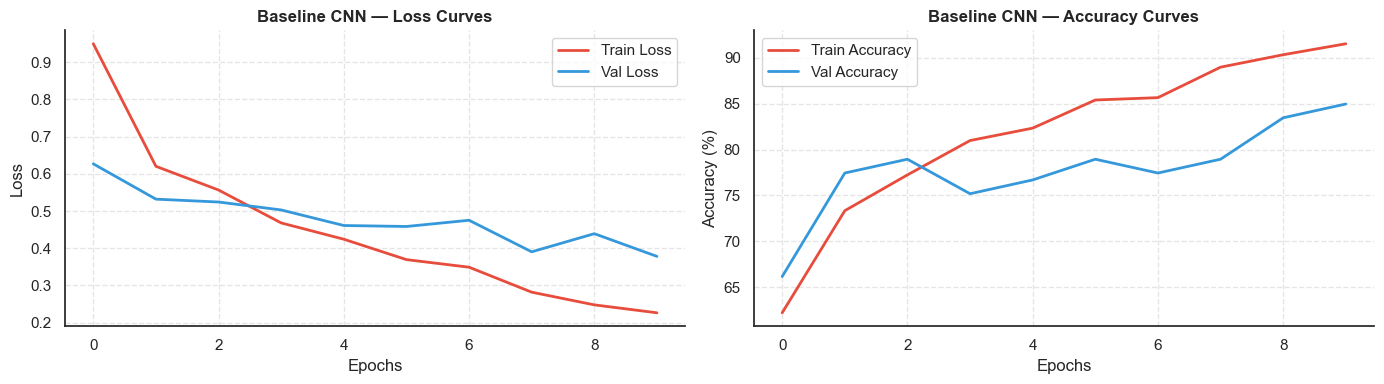

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_losses, label="Train Loss",     color="#e74c3c", linewidth=2)
axes[0].plot(val_losses,   label="Val Loss",       color="#3498db", linewidth=2)
axes[0].set_title("Baseline CNN — Loss Curves",    fontweight="bold")
axes[0].set_xlabel("Epochs"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(train_accs, label="Train Accuracy",   color="#e74c3c", linewidth=2)
axes[1].plot(val_accs,   label="Val Accuracy",     color="#3498db", linewidth=2)
axes[1].set_title("Baseline CNN — Accuracy Curves", fontweight="bold")
axes[1].set_xlabel("Epochs"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("baseline_curves.png", dpi=150)
plt.show()

## 9. Baseline CNN Evaluation

In [25]:
model.eval()
all_preds_b, all_labels_b, all_probs_b, all_images_b = [], [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs   = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        all_preds_b.extend(preds.cpu().numpy())
        all_labels_b.extend(labels.cpu().numpy())
        all_probs_b.extend(probs.cpu().numpy())
        all_images_b.extend(images.cpu())

all_preds_b  = np.array(all_preds_b)
all_labels_b = np.array(all_labels_b)
all_probs_b  = np.array(all_probs_b)

In [26]:
baseline_acc = accuracy_score(all_labels_b, all_preds_b)
print("="*50)
print(f" Baseline CNN — Test Accuracy: {baseline_acc*100:.2f}%")
print("="*50)
print(classification_report(all_labels_b, all_preds_b, target_names=class_names))

 Baseline CNN — Test Accuracy: 85.94%
                   precision    recall  f1-score   support

angular_leaf_spot       0.92      0.77      0.84       129
        bean_rust       0.78      0.88      0.83       129
          healthy       0.91      0.93      0.92       126

         accuracy                           0.86       384
        macro avg       0.87      0.86      0.86       384
     weighted avg       0.87      0.86      0.86       384



In [27]:
cm_b = confusion_matrix(all_labels_b, all_preds_b)
per_class_b = cm_b.diagonal() / cm_b.sum(axis=1)

print("Per-Class Accuracy — Baseline CNN:")
print("-"*40)
for i, cls in enumerate(class_names):
    print(f"  {cls:<25}: {per_class_b[i]*100:.2f}%")

Per-Class Accuracy — Baseline CNN:
----------------------------------------
  angular_leaf_spot        : 76.74%
  bean_rust                : 88.37%
  healthy                  : 92.86%


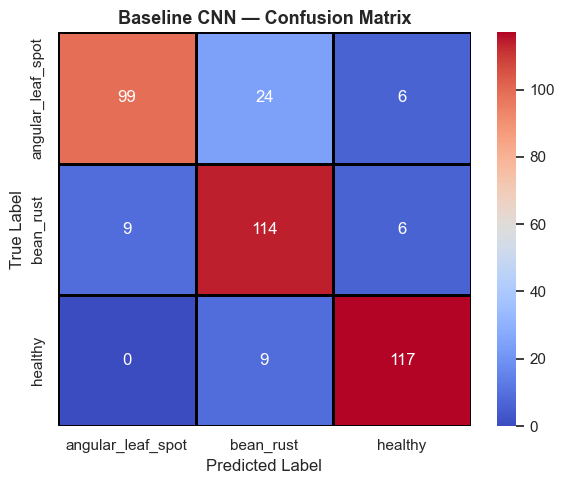

In [28]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm_b, annot=True, fmt="d",
            cmap="coolwarm",
            linewidths=1, linecolor="black",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Baseline CNN — Confusion Matrix", fontweight="bold", fontsize=13)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("cm_baseline.png", dpi=300, bbox_inches="tight")
plt.show()

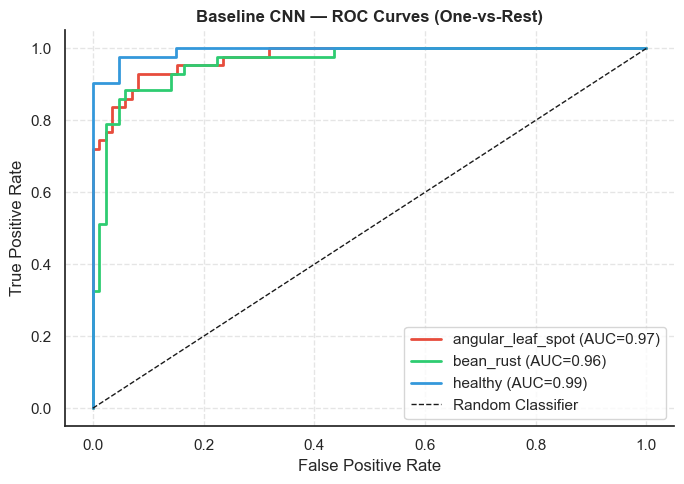

In [29]:
labels_bin_b = label_binarize(all_labels_b, classes=[0, 1, 2])
colors = ["#e74c3c", "#2ecc71", "#3498db"]

plt.figure(figsize=(7, 5))
for i, (cls, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(labels_bin_b[:, i], all_probs_b[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{cls} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Baseline CNN — ROC Curves (One-vs-Rest)", fontweight="bold")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("roc_baseline.png", dpi=150)
plt.show()

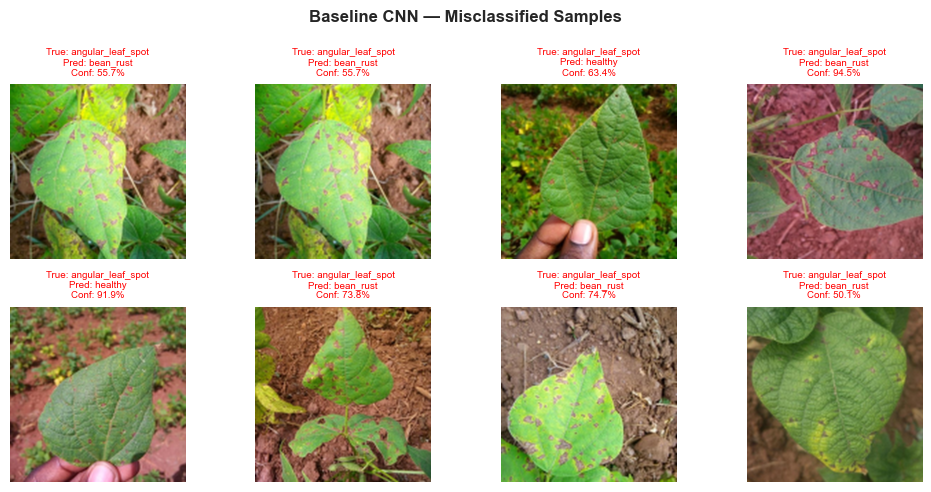

In [30]:
wrong_idx = np.where(all_preds_b != all_labels_b)[0]
show_n = min(8, len(wrong_idx))
fig, axes = plt.subplots(2, 4, figsize=(10, 5))  # smaller figure = less stretching
axes = axes.flatten()
mean_np = np.array([0.485, 0.456, 0.406])
std_np  = np.array([0.229, 0.224, 0.225])

for i, idx in enumerate(wrong_idx[:show_n]):
    img = all_images_b[idx].permute(1, 2, 0).numpy()
    img = (img * std_np) + mean_np
    img = img.clip(0, 1)
    axes[i].imshow(img, interpolation="lanczos")  # smoother upscaling
    axes[i].set_title(
        f"True: {class_names[all_labels_b[idx]]}\nPred: {class_names[all_preds_b[idx]]}\nConf: {all_probs_b[idx].max()*100:.1f}%",
        fontsize=7, color="red")
    axes[i].axis("off")

for j in range(show_n, 8):
    axes[j].axis("off")

plt.suptitle("Baseline CNN — Misclassified Samples", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("misclassified_baseline.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Improved CNN Architecture & Training

In [32]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes):
        super(ImprovedCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        
        self.pool = nn.MaxPool2d(2,2)
        
        self.dropout = nn.Dropout(0.5)   # important
        
        self.fc1 = nn.Linear(128 * 16 * 16, 256)  # 128x128 → 16x16 after 3 pools
        self.fc2 = nn.Linear(256, num_classes)
    
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 64x64
        x = self.pool(F.relu(self.conv2(x)))  # 32x32
        x = self.pool(F.relu(self.conv3(x)))  # 16x16
        
        x = x.view(x.size(0), -1)
        
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        
        return x

In [33]:
improved_model = ImprovedCNN(num_classes).to(device)

print(improved_model)

ImprovedCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=32768, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=3, bias=True)
)


In [34]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(improved_model.parameters(), lr=0.0005)  # lower LR

EPOCHS = 15   # more training
BATCH_SIZE = 32

In [35]:
start_improved = time.time()

train_losses_imp, val_losses_imp, train_accs_imp, val_accs_imp = train_model(
    improved_model, train_loader, val_loader, criterion, optimizer, epochs=EPOCHS
)

improved_time = time.time() - start_improved
print(f"Improved CNN Training Time: {improved_time:.1f}s")

/opt/homebrew/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/15]
Train Loss: 0.9536 | Train Acc: 55.06%
Val Loss: 0.7207 | Val Acc: 64.66%
----------------------------------------
Epoch [2/15]
Train Loss: 0.7234 | Train Acc: 67.86%
Val Loss: 0.6128 | Val Acc: 75.19%
----------------------------------------
Epoch [3/15]
Train Loss: 0.6231 | Train Acc: 73.82%
Val Loss: 0.5697 | Val Acc: 74.44%
----------------------------------------
Epoch [4/15]
Train Loss: 0.5875 | Train Acc: 75.31%
Val Loss: 0.5373 | Val Acc: 75.94%
----------------------------------------
Epoch [5/15]
Train Loss: 0.5356 | Train Acc: 78.21%
Val Loss: 0.5163 | Val Acc: 73.68%
----------------------------------------
Epoch [6/15]
Train Loss: 0.4879 | Train Acc: 80.56%
Val Loss: 0.4142 | Val Acc: 81.95%
----------------------------------------
Epoch [7/15]
Train Loss: 0.4670 | Train Acc: 81.37%
Val Loss: 0.4149 | Val Acc: 82.71%
----------------------------------------
Epoch [8/15]
Train Loss: 0.4145 | Train Acc: 82.59%
Val Loss: 0.4634 | Val Acc: 75.94%
-----------------

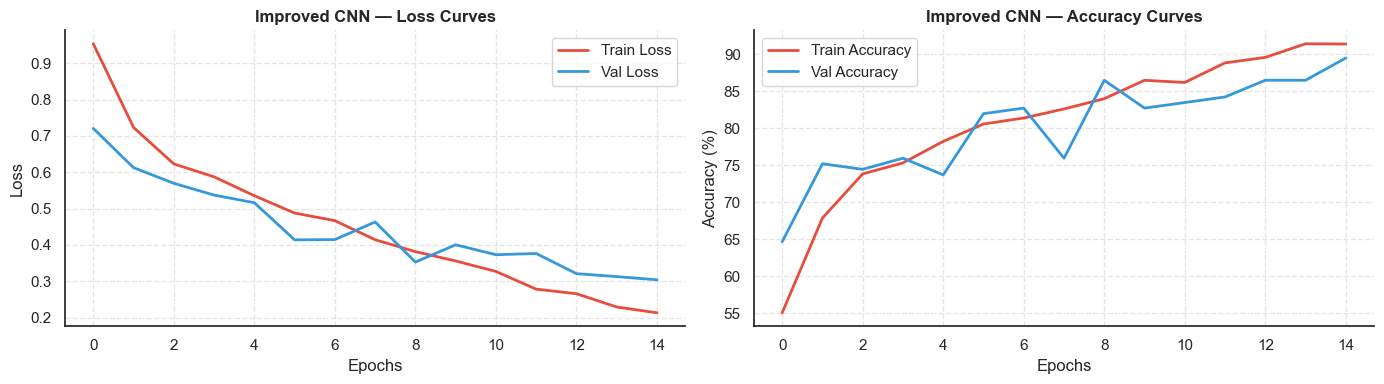

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_losses_imp, label="Train Loss",    color="#e74c3c", linewidth=2)
axes[0].plot(val_losses_imp,   label="Val Loss",      color="#3498db", linewidth=2)
axes[0].set_title("Improved CNN — Loss Curves",       fontweight="bold")
axes[0].set_xlabel("Epochs"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(train_accs_imp, label="Train Accuracy",  color="#e74c3c", linewidth=2)
axes[1].plot(val_accs_imp,   label="Val Accuracy",    color="#3498db", linewidth=2)
axes[1].set_title("Improved CNN — Accuracy Curves",  fontweight="bold")
axes[1].set_xlabel("Epochs"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("improved_curves.png", dpi=150)
plt.show()

In [37]:
def evaluate_model(model, data_loader, class_names):
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Return metrics for separate printing
    acc = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names)
    cm = confusion_matrix(all_labels, all_preds)
    
    return acc, report, cm

In [38]:
improved_acc, improved_report, improved_cm = evaluate_model(
    improved_model, test_loader, class_names
)
print("="*50)
print(f" Improved CNN — Test Accuracy: {improved_acc*100:.2f}%")
print("="*50)

 Improved CNN — Test Accuracy: 89.06%


In [40]:
print(" Classification Report:\n")
print(improved_report)

per_class_imp = improved_cm.diagonal() / improved_cm.sum(axis=1)
print("Per-Class Accuracy — Improved CNN:")
print("-"*40)
for i, cls in enumerate(class_names):
    print(f"  {cls:<25}: {per_class_imp[i]*100:.2f}%")

 Classification Report:

                   precision    recall  f1-score   support

angular_leaf_spot       0.90      0.86      0.88       129
        bean_rust       0.84      0.86      0.85       129
          healthy       0.93      0.95      0.94       126

         accuracy                           0.89       384
        macro avg       0.89      0.89      0.89       384
     weighted avg       0.89      0.89      0.89       384

Per-Class Accuracy — Improved CNN:
----------------------------------------
  angular_leaf_spot        : 86.05%
  bean_rust                : 86.05%
  healthy                  : 95.24%


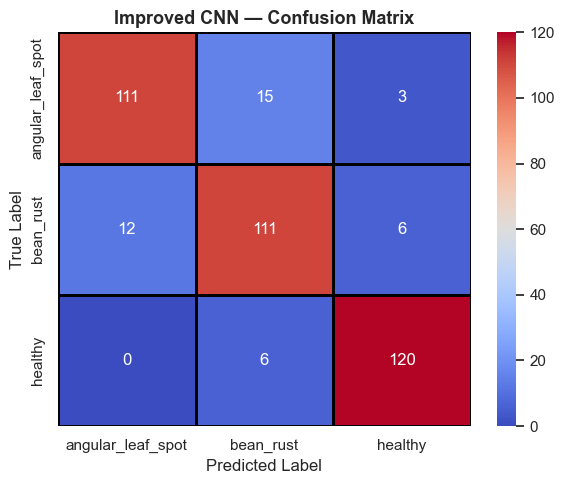

In [41]:
plt.figure(figsize=(6, 5))
sns.heatmap(improved_cm, annot=True, fmt="d",
            cmap="coolwarm",
            linewidths=1, linecolor="black",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Improved CNN — Confusion Matrix", fontweight="bold", fontsize=13)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("cm_improved.png", dpi=300, bbox_inches="tight")
plt.show()

In [42]:
print("\n  MODEL COMPARISON (so far)")
print("="*45)
print(f"  Baseline CNN : {baseline_acc*100:.2f}%")
print(f"  Improved CNN : {improved_acc*100:.2f}%")
print("="*45)


  MODEL COMPARISON (so far)
  Baseline CNN : 85.94%
  Improved CNN : 89.06%


## 11. Transfer Learning (ResNet18)

In [43]:
resnet_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
]) 

resnet_val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

resnet_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
]) 

resnet_val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])


res_train_data = datasets.ImageFolder("dataset/train", transform=resnet_train_transform)
res_val_data   = datasets.ImageFolder("dataset/val",   transform=resnet_val_test_transform)
res_test_data  = datasets.ImageFolder("dataset/test",  transform=resnet_val_test_transform)

BATCH_SIZE = 64

res_train_loader = DataLoader(
    res_train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,          # shuffle for training
    num_workers=2,
    pin_memory=True
)

res_val_loader = DataLoader(
    res_val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

res_test_loader = DataLoader(
    res_test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [44]:
model_ft = models.resnet18(pretrained=True)

/opt/homebrew/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [45]:
for param in model_ft.parameters():
    param.requires_grad = False

for param in model_ft.layer4.parameters():
    param.requires_grad = True


In [46]:
num_features = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_features, num_classes)

In [47]:
model_ft = model_ft.to(device)

print(model_ft)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [48]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    list(model_ft.layer4.parameters()) + list(model_ft.fc.parameters()),
    lr=0.0001
)

In [49]:
start_resnet = time.time()

train_losses_ft, val_losses_ft, train_accs_ft, val_accs_ft = train_model(
    model_ft, res_train_loader, res_val_loader, criterion, optimizer, epochs=5
)

resnet_time = time.time() - start_resnet
print(f"ResNet18 Training Time: {resnet_time:.1f}s")

/opt/homebrew/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/5]
Train Loss: 0.3250 | Train Acc: 87.94%
Val Loss: 0.1923 | Val Acc: 91.73%
----------------------------------------
Epoch [2/5]
Train Loss: 0.0722 | Train Acc: 98.26%
Val Loss: 0.1676 | Val Acc: 93.98%
----------------------------------------
Epoch [3/5]
Train Loss: 0.0366 | Train Acc: 99.10%
Val Loss: 0.1185 | Val Acc: 95.49%
----------------------------------------
Epoch [4/5]
Train Loss: 0.0228 | Train Acc: 99.45%
Val Loss: 0.1633 | Val Acc: 94.74%
----------------------------------------
Epoch [5/5]
Train Loss: 0.0115 | Train Acc: 99.94%
Val Loss: 0.1144 | Val Acc: 95.49%
----------------------------------------
ResNet18 Training Time: 434.2s


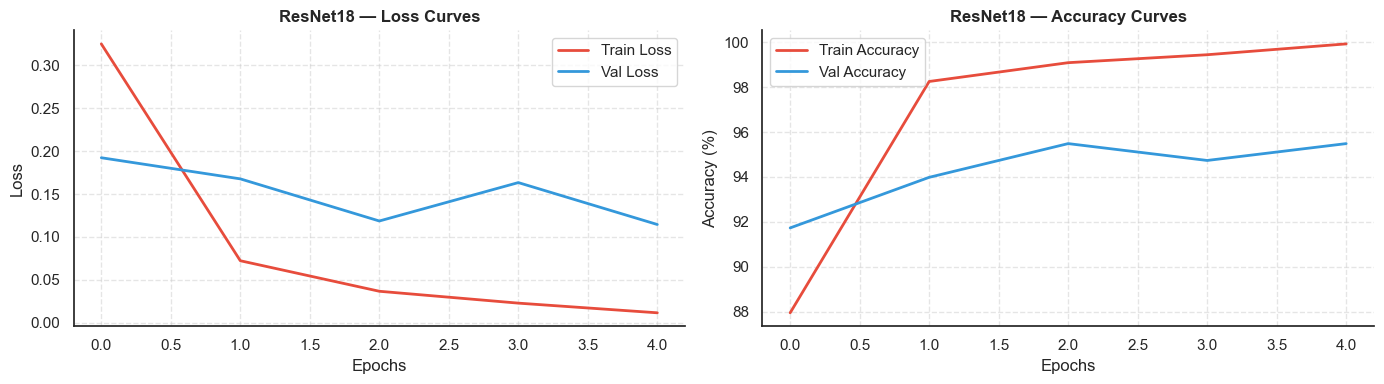

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_losses_ft, label="Train Loss",   color="#e74c3c", linewidth=2)
axes[0].plot(val_losses_ft,   label="Val Loss",     color="#3498db", linewidth=2)
axes[0].set_title("ResNet18 — Loss Curves",         fontweight="bold")
axes[0].set_xlabel("Epochs"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(train_accs_ft, label="Train Accuracy", color="#e74c3c", linewidth=2)
axes[1].plot(val_accs_ft,   label="Val Accuracy",   color="#3498db", linewidth=2)
axes[1].set_title("ResNet18 — Accuracy Curves",    fontweight="bold")
axes[1].set_xlabel("Epochs"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("resnet_curves.png", dpi=500)
plt.show()

In [51]:
ft_accuracy, ft_report, ft_cm = evaluate_model(
    model_ft, res_test_loader, class_names
)
print("="*50)
print(f" ResNet18 — Test Accuracy: {ft_accuracy*100:.2f}%")
print("="*50)

 ResNet18 — Test Accuracy: 94.53%


In [52]:
print(" Classification Report:\n")
print(ft_report)

per_class_ft = ft_cm.diagonal() / ft_cm.sum(axis=1)
print("Per-Class Accuracy — ResNet18:")
print("-"*40)
for i, cls in enumerate(class_names):
    print(f"  {cls:<25}: {per_class_ft[i]*100:.2f}%")

 Classification Report:

                   precision    recall  f1-score   support

angular_leaf_spot       0.93      0.93      0.93       129
        bean_rust       0.91      0.95      0.93       129
          healthy       1.00      0.95      0.98       126

         accuracy                           0.95       384
        macro avg       0.95      0.95      0.95       384
     weighted avg       0.95      0.95      0.95       384

Per-Class Accuracy — ResNet18:
----------------------------------------
  angular_leaf_spot        : 93.02%
  bean_rust                : 95.35%
  healthy                  : 95.24%


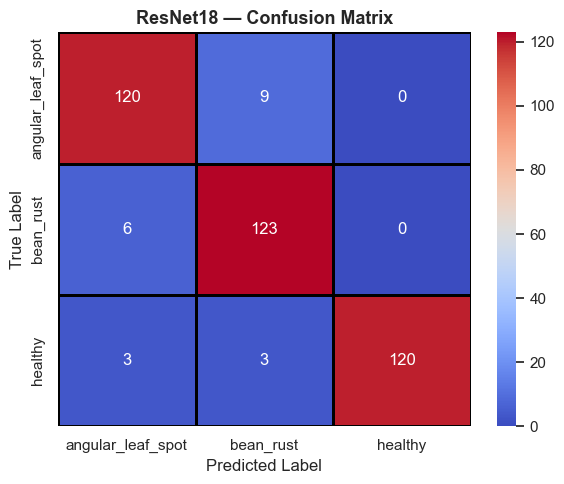

In [53]:
plt.figure(figsize=(6, 5))
sns.heatmap(ft_cm, annot=True, fmt="d",
            cmap="coolwarm",
            linewidths=1, linecolor="black",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("ResNet18 — Confusion Matrix", fontweight="bold", fontsize=13)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("cm_resnet.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Final Model Comparison

In [54]:
def get_metrics(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        "Accuracy": report["accuracy"],
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-score": report["weighted avg"]["f1-score"]
    }

# Helper function to get predictions for models that don't have global prediction arrays yet
def get_predictions(model, loader):
    model.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_p.extend(preds.cpu().numpy())
            all_l.extend(labels.numpy())
    return all_l, all_p

# 1. Baseline predictions were already saved in `all_labels_b` and `all_preds_b` earlier in the notebook
y_true_base, y_pred_base = all_labels_b, all_preds_b

# 2. Get predictions for Improved CNN and ResNet18
y_true_imp, y_pred_imp = get_predictions(improved_model, test_loader)
y_true_res, y_pred_res = get_predictions(model_ft, res_test_loader)

# Calculate metrics
baseline_metrics = get_metrics(y_true_base, y_pred_base)
improved_metrics = get_metrics(y_true_imp, y_pred_imp)
resnet_metrics   = get_metrics(y_true_res, y_pred_res)

# Create DataFrame
comparison_df = pd.DataFrame({
    "Baseline CNN": baseline_metrics,
    "Improved CNN": improved_metrics,
    "ResNet18 (Transfer Learning)": resnet_metrics
}).T

# Format to percentage
comparison_df = (comparison_df * 100).round(2).astype(str) + '%'
comparison_df

/opt/homebrew/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


,Accuracy,Precision,Recall,F1-score
Baseline CNN,85.94%,86.61%,85.94%,85.93%
Improved CNN,89.06%,89.09%,89.06%,89.05%
ResNet18 (Transfer Learning),94.53%,94.67%,94.53%,94.57%


In [55]:
print("\n FINAL MODEL COMPARISON")
print("="*58)
print(f"  {'Model':<30} {'Accuracy':>10} {'Train Time':>12}")
print("-"*58)
print(f"  {'Baseline CNN':<30} {baseline_acc*100:>9.2f}%  {baseline_time:>8.1f}s")
print(f"  {'Improved CNN':<30} {improved_acc*100:>9.2f}%  {improved_time:>8.1f}s")
print(f"  {'ResNet18 (Transfer Learning)':<30} {ft_accuracy*100:>9.2f}%  {resnet_time:>8.1f}s")
print("="*58)
print()
print(f"  {'Class':<25} {'Baseline':>10} {'Improved':>10} {'ResNet18':>10}")
print("-"*58)
for i, cls in enumerate(class_names):
    print(f"  {cls:<25} {per_class_b[i]*100:>9.2f}% {per_class_imp[i]*100:>9.2f}% {per_class_ft[i]*100:>9.2f}%")
print("="*58)


 FINAL MODEL COMPARISON
  Model                            Accuracy   Train Time
----------------------------------------------------------
  Baseline CNN                       85.94%     281.2s
  Improved CNN                       89.06%     553.1s
  ResNet18 (Transfer Learning)       94.53%     434.2s

  Class                       Baseline   Improved   ResNet18
----------------------------------------------------------
  angular_leaf_spot             76.74%     86.05%     93.02%
  bean_rust                     88.37%     86.05%     95.35%
  healthy                       92.86%     95.24%     95.24%


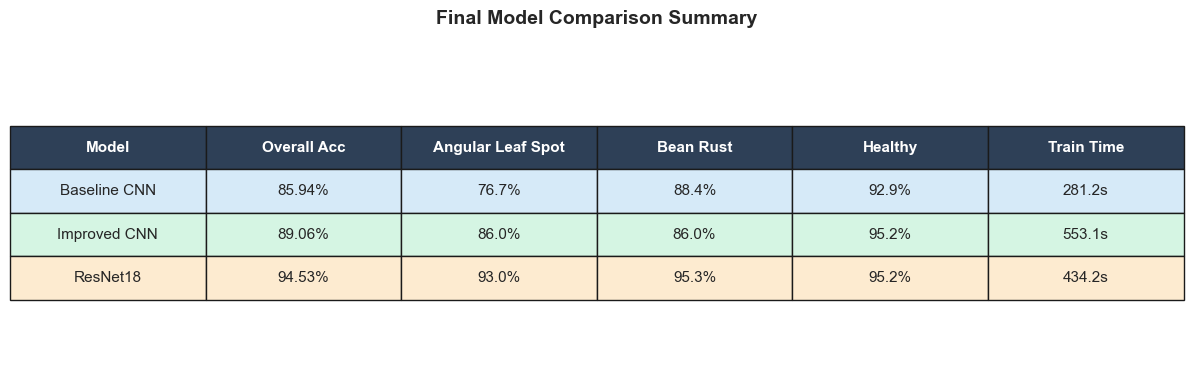

In [56]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

table_data = [
    ["Baseline CNN",   f"{baseline_acc*100:.2f}%",   f"{per_class_b[0]*100:.1f}%",   f"{per_class_b[1]*100:.1f}%",   f"{per_class_b[2]*100:.1f}%",   f"{baseline_time:.1f}s"],
    ["Improved CNN",   f"{improved_acc*100:.2f}%",   f"{per_class_imp[0]*100:.1f}%", f"{per_class_imp[1]*100:.1f}%", f"{per_class_imp[2]*100:.1f}%", f"{improved_time:.1f}s"],
    ["ResNet18",       f"{ft_accuracy*100:.2f}%",    f"{per_class_ft[0]*100:.1f}%",  f"{per_class_ft[1]*100:.1f}%",  f"{per_class_ft[2]*100:.1f}%",  f"{resnet_time:.1f}s"],
]

columns = ["Model", "Overall Acc", "Angular Leaf Spot", "Bean Rust", "Healthy", "Train Time"]
colors_row = ["#d6eaf8", "#d5f5e3", "#fdebd0"]

table = ax.table(
    cellText=table_data,
    colLabels=columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.5)

# Header styling
for j in range(len(columns)):
    table[0, j].set_facecolor("#2E4057")
    table[0, j].set_text_props(color="white", fontweight="bold")

# Row styling
for i, color in enumerate(colors_row):
    for j in range(len(columns)):
        table[i+1, j].set_facecolor(color)
        table[i+1, j].set_text_props(fontsize=11)

plt.title("Final Model Comparison Summary", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("final_summary_table.png", dpi=300, bbox_inches="tight")
plt.show()

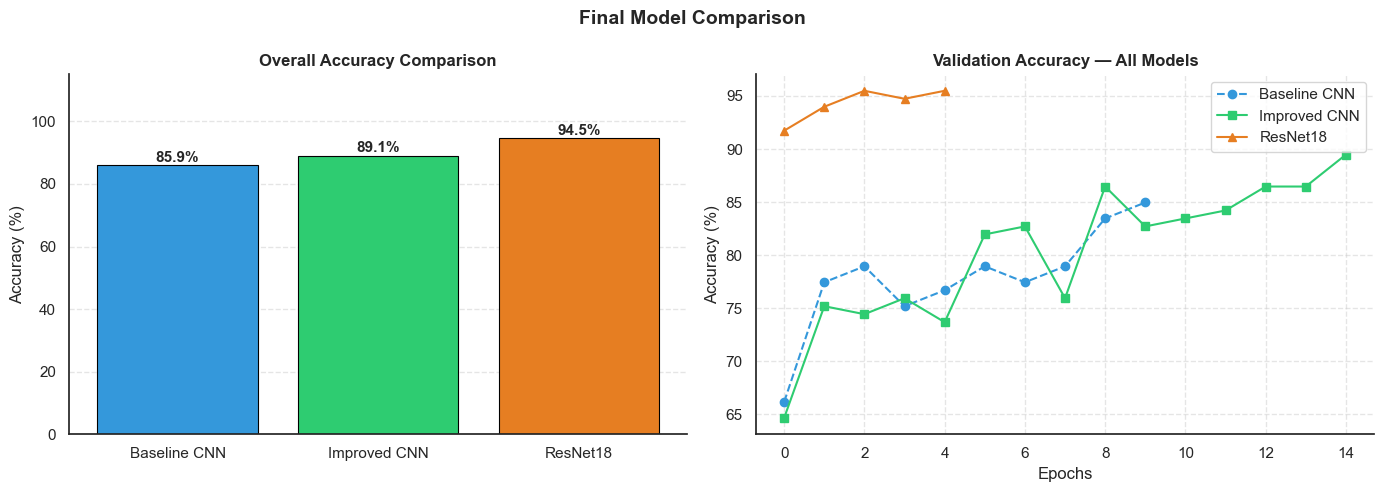

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_labels = ["Baseline CNN", "Improved CNN", "ResNet18"]
accs   = [baseline_acc*100, improved_acc*100, ft_accuracy*100]
colors = ["#3498db", "#2ecc71", "#e67e22"]

bars = axes[0].bar(model_labels, accs, color=colors, edgecolor="black", linewidth=0.8)
axes[0].set_title("Overall Accuracy Comparison", fontweight="bold", fontsize=12)
axes[0].set_ylabel("Accuracy (%)"); axes[0].set_ylim(0, 115)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{acc:.1f}%", ha="center", fontweight="bold", fontsize=11)

axes[1].plot(val_accs,     label="Baseline CNN", linestyle="--", marker="o", color="#3498db")
axes[1].plot(val_accs_imp, label="Improved CNN", marker="s",                 color="#2ecc71")
axes[1].plot(val_accs_ft,  label="ResNet18",     marker="^",                 color="#e67e22")
axes[1].set_title("Validation Accuracy — All Models", fontweight="bold", fontsize=12)
axes[1].set_xlabel("Epochs"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(True, linestyle="--", alpha=0.5)

plt.suptitle("Final Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("final_comparison.png", dpi=150)
plt.show()

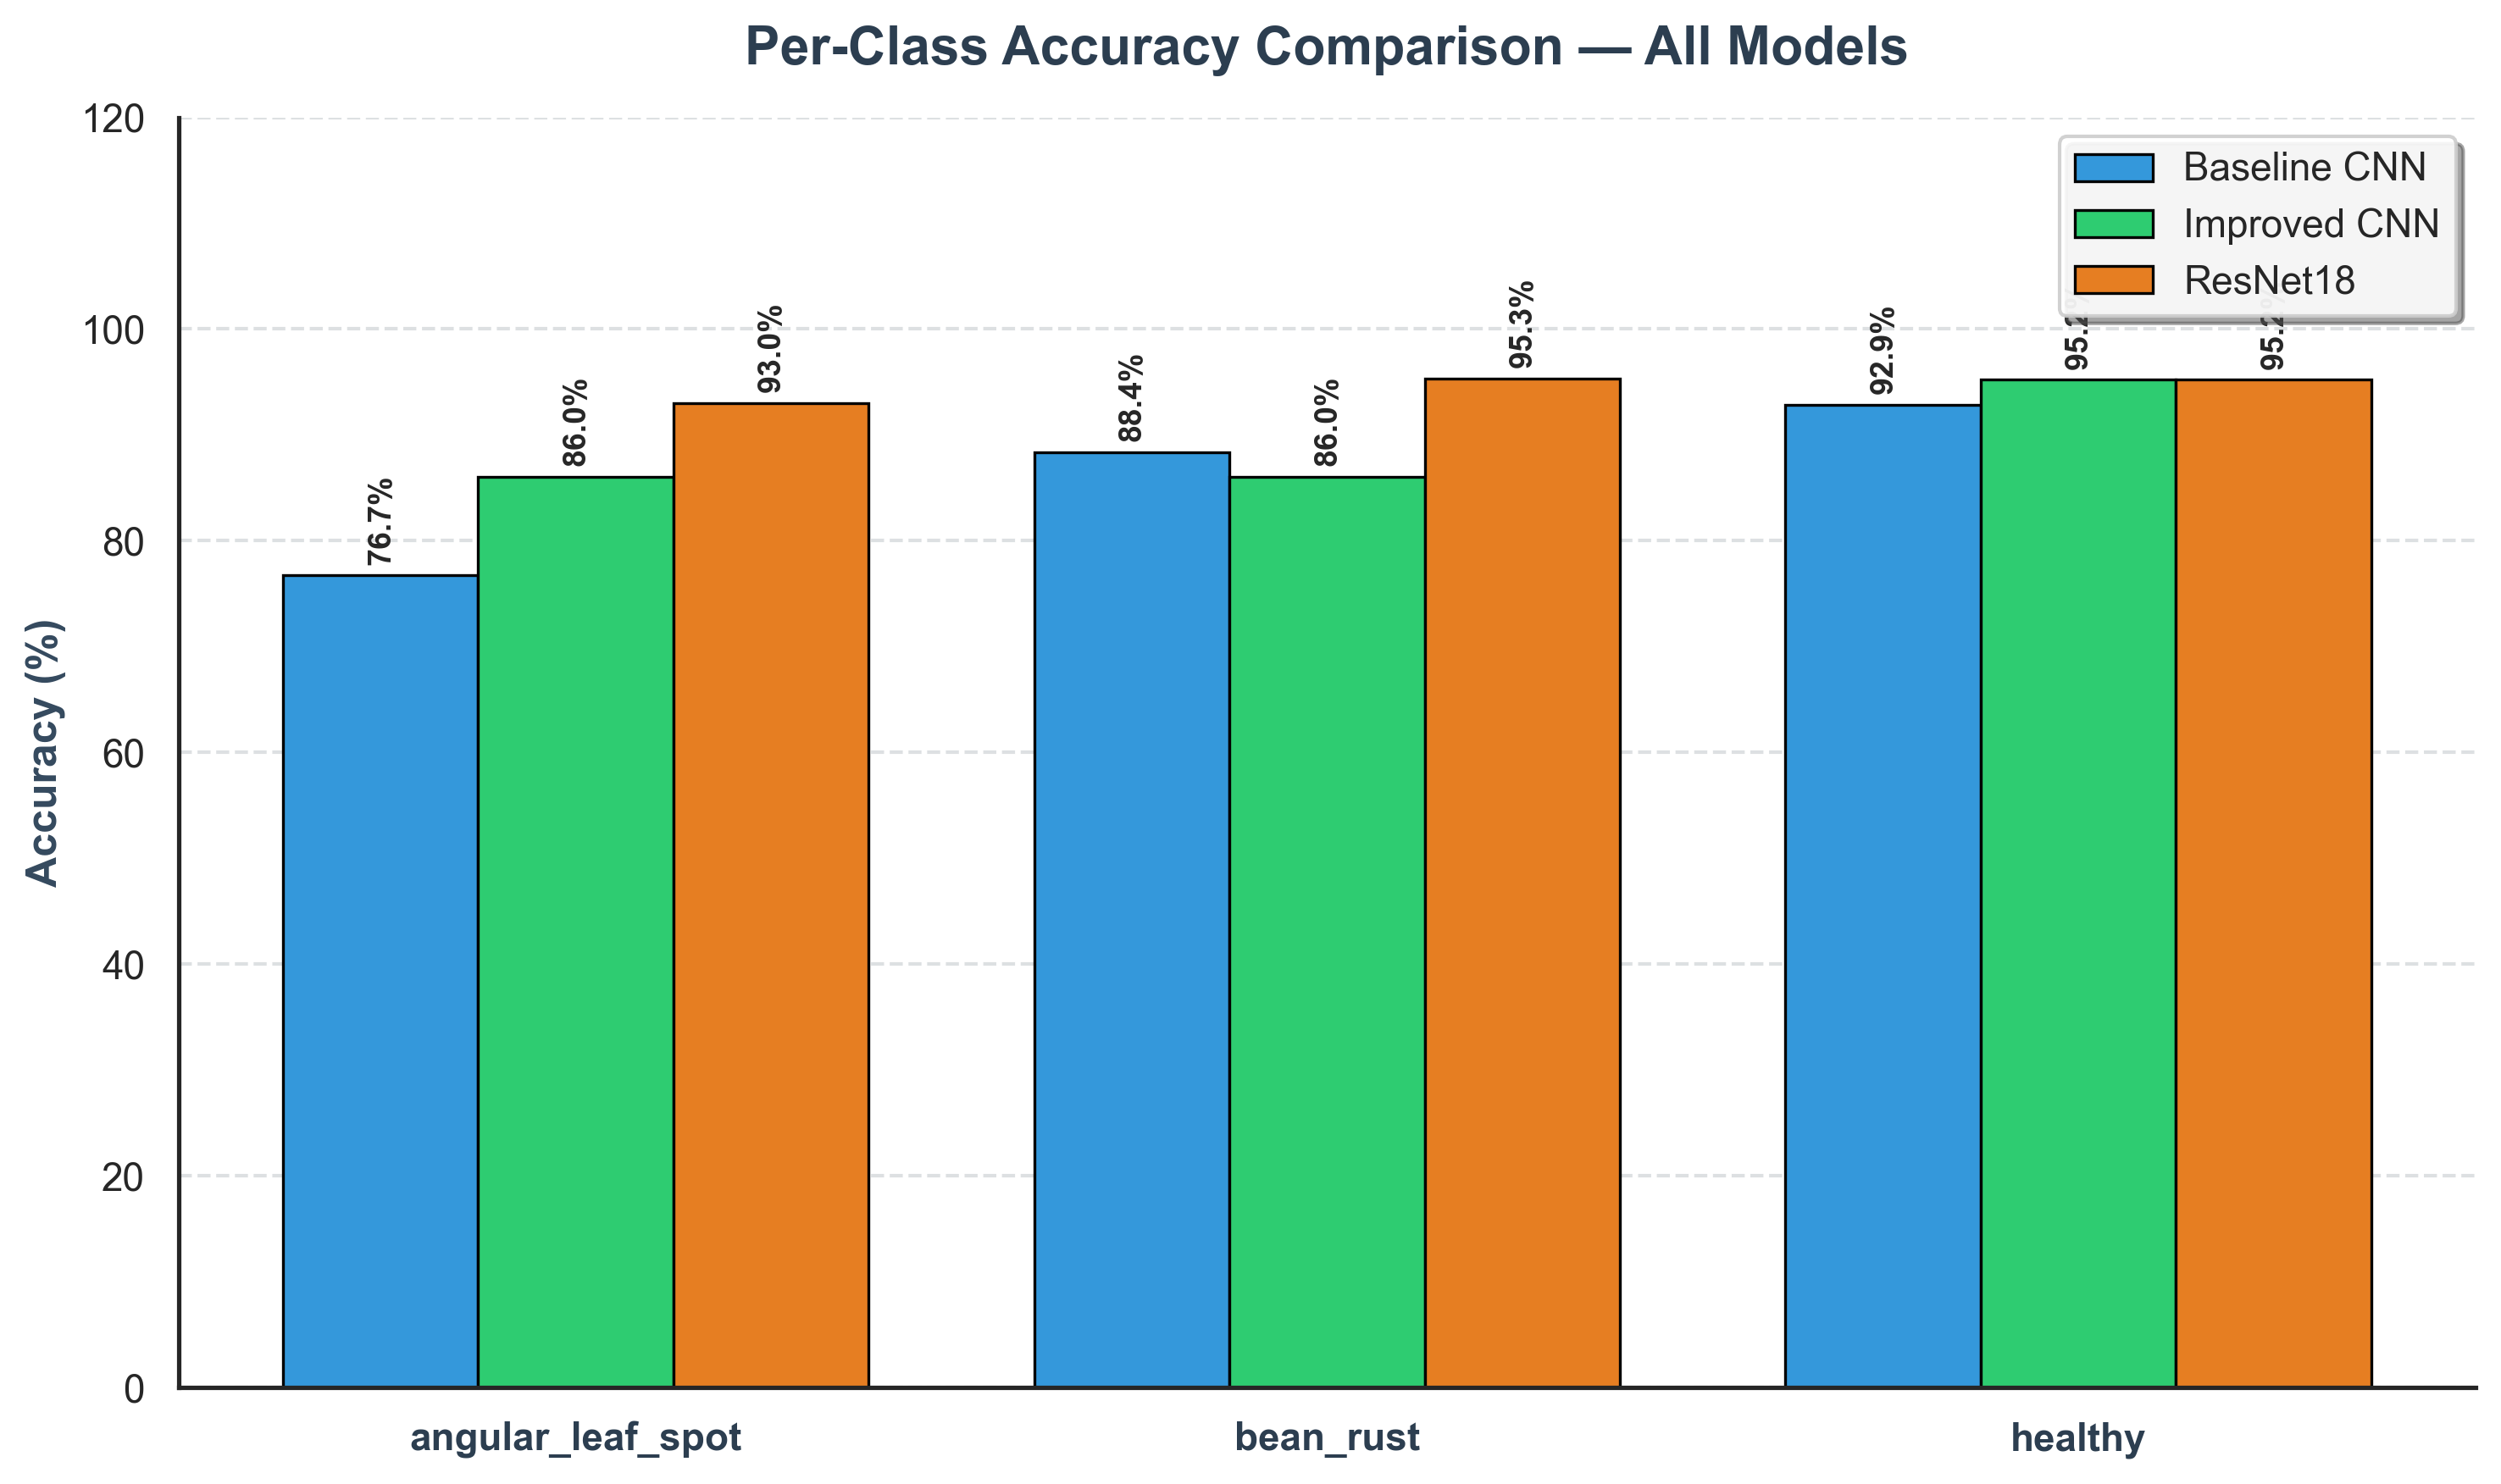

In [58]:
x = np.arange(len(class_names))
width = 0.26  # Slightly tweaked for better spacing

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
rects1 = ax.bar(x - width, per_class_b*100,   width, label="Baseline CNN", color="#3498db", edgecolor="black", linewidth=0.8)
rects2 = ax.bar(x,         per_class_imp*100, width, label="Improved CNN", color="#2ecc71", edgecolor="black", linewidth=0.8)
rects3 = ax.bar(x + width, per_class_ft*100,  width, label="ResNet18",     color="#e67e22", edgecolor="black", linewidth=0.8)

# Add percentage labels on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold', rotation=90)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

ax.set_title("Per-Class Accuracy Comparison — All Models", fontweight="bold", fontsize=15, pad=15, color="#2c3e50")
ax.set_ylabel("Accuracy (%)", fontsize=12, fontweight="bold", color="#34495e")
ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=11, fontweight="bold", rotation=0, color="#2c3e50")  # Removed rotation if names are short enough
ax.set_ylim(0, 120)  # slightly increased top limit to fit labels 
ax.legend(loc='upper right', framealpha=0.9, shadow=True)
ax.grid(axis="y", linestyle="--", alpha=0.5, color="#bdc3c7")

plt.tight_layout()
plt.savefig("per_class_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

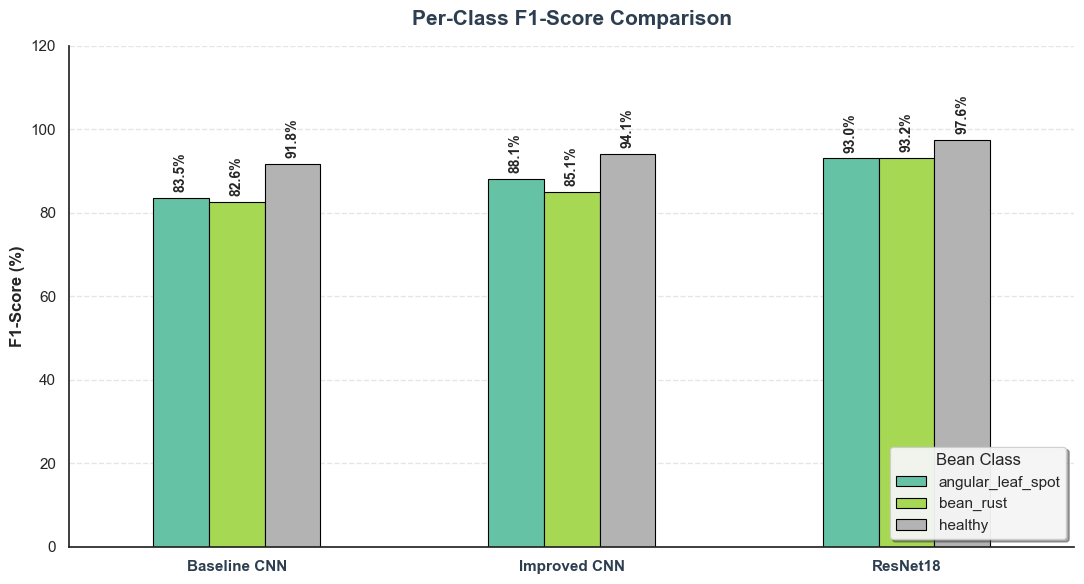

In [59]:
# Calculate per-class F1-scores for a more detailed comparison
def get_per_class_f1(y_true, y_pred, class_names):
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    return {cls: report[cls]["f1-score"] for cls in class_names}

f1_base = get_per_class_f1(y_true_base, y_pred_base, class_names)
f1_imp  = get_per_class_f1(y_true_imp, y_pred_imp, class_names)
f1_res  = get_per_class_f1(y_true_res, y_pred_res, class_names)

# Create DataFrame
f1_df = pd.DataFrame({
    "Baseline CNN": f1_base,
    "Improved CNN": f1_imp,
    "ResNet18": f1_res
}).T * 100

# Plotting
ax = f1_df.plot(kind='bar', figsize=(11, 6), edgecolor='black', linewidth=0.8, colormap="Set2")

plt.title("Per-Class F1-Score Comparison", fontsize=15, fontweight='bold', pad=15, color="#2c3e50")
plt.ylabel("F1-Score (%)", fontsize=12, fontweight='bold')
plt.xticks(rotation=0, fontweight='bold', fontsize=11, color="#2c3e50")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Bean Class", loc='lower right', framealpha=0.9, shadow=True)
plt.ylim(0, 120)

# Add values on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, fontweight='bold', 
                rotation=90, xytext=(0, 4), textcoords='offset points')

plt.tight_layout()
plt.savefig("per_class_f1_comparison.png", dpi=300)
plt.show()

In [60]:
torch.save(model.state_dict(), 'baseline_cnn.pth')
torch.save(improved_model.state_dict(), 'improved_cnn.pth')
torch.save(model_ft.state_dict(), 'resnet18_ft.pth')
print("All models saved!")

All models saved!


In [61]:
import json
with open('classes.json', 'w') as f:
    json.dump(train_data.classes, f)
print("Classes saved:", train_data.classes)

Classes saved: ['angular_leaf_spot', 'bean_rust', 'healthy']
